# A simple model: can a real MMM recover a known world?

[The data-generation tour](index.ipynb) built worlds from the smallest graph
to a confounded one. This notebook asks the estimation question: draw **one
deliberately favourable world** — causal sufficiency holds, one media
response family, healthy spend variation — hand a stock
`pymc_marketing.mmm.MMM` its observables, and score it against the known
truth. Then fit the generator's own **posterior oracle** on the same data
and compare.

The punchline is worth stating up front, because it is measured below:

1. the MMM's weekly *shape* is nearly perfect, its cumulative *attribution*
   is off by 19–36% with intervals that miss — and its sampler diagnostics
   look clean, so nothing warns you;
2. the oracle recovers every channel within a few percent, with 3/3
   coverage and the true parameters inside tight posteriors —
   **the world was identified; the gap is the estimator's error model**.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
import tempfile
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import Image, display

from pymc_marketing.mmm import MMM, GeometricAdstock, MichaelisMentenSaturation

import prior_generator as pg
from prior_generator import viz
from prior_generator.sampler import ADSTOCK_FAMILY_KEYS, SATURATION_FAMILY_KEYS

print('prior-generator', pg.__version__)

prior-generator 0.0.1


## 1 · One causally sufficient world

Three channels feed sales directly; two observed controls feed the baseline
only; the latent demand slot is present but **isolated** (every `D` edge
budget is zero) and `rho = 0`, so there is no unobserved common cause of
spend and sales. A regression on the observables is licensed — whatever
fails below will not be an identification failure.

One functional form everywhere, and it is the exact pair the MMM will use:
normalized geometric adstock (`l_max=4`) × Michaelis-Menten saturation.

In [2]:
def pin(adstock, saturation):
    """Family probability dicts that select exactly one family each."""
    return {
        'adstock_family_probs': {**dict.fromkeys(ADSTOCK_FAMILY_KEYS, 0.0), adstock: 1.0},
        'saturation_family_probs': {
            **dict.fromkeys(SATURATION_FAMILY_KEYS, 0.0), saturation: 1.0
        },
    }

cfg = pg.make_scm_prior(
    n_treatments=3, n_covariates=2, n_latent=1, T=104, l_max=4,
    n_treatments_active_range=(3, 3), n_covariates_active_range=(2, 2),
    n_latent_active_range=(1, 1),
    edge_budget={'cy': (3, 3), 'zb': (2, 2), 'db': (0, 0), 'dc': (0, 0),
                 'dz': (0, 0), 'zc': (0, 0), 'cc': (0, 0), 'zz': (0, 0)},
    confounding_strength_range=(0.0, 0.0),   # rho = 0: fully Markovian
    n_cells=2, draws_per_cell=1, seed=20260728,
    **pin('geometric', 'michaelis_menten'),
)
world = pg.sample_scm(cfg, seed=22, name='sufficient')

# The drawn world IS the graph we asked for.
assert world.g['g_cy'].all() and world.g['g_zb'].all()
for name in ('g_db', 'g_dc', 'g_dz', 'g_zc', 'g_cc', 'g_zz'):
    assert not world.g[name].any(), name
assert float(world.data['confounding_strength']) == 0.0
assert world.identity_error() < 1e-9
print(f'T={world.T}  K={world.K} channels  M={world.M} controls  '
      f'J={world.J} latent (isolated)')

T=104  K=3 channels  M=2 controls  J=1 latent (isolated)


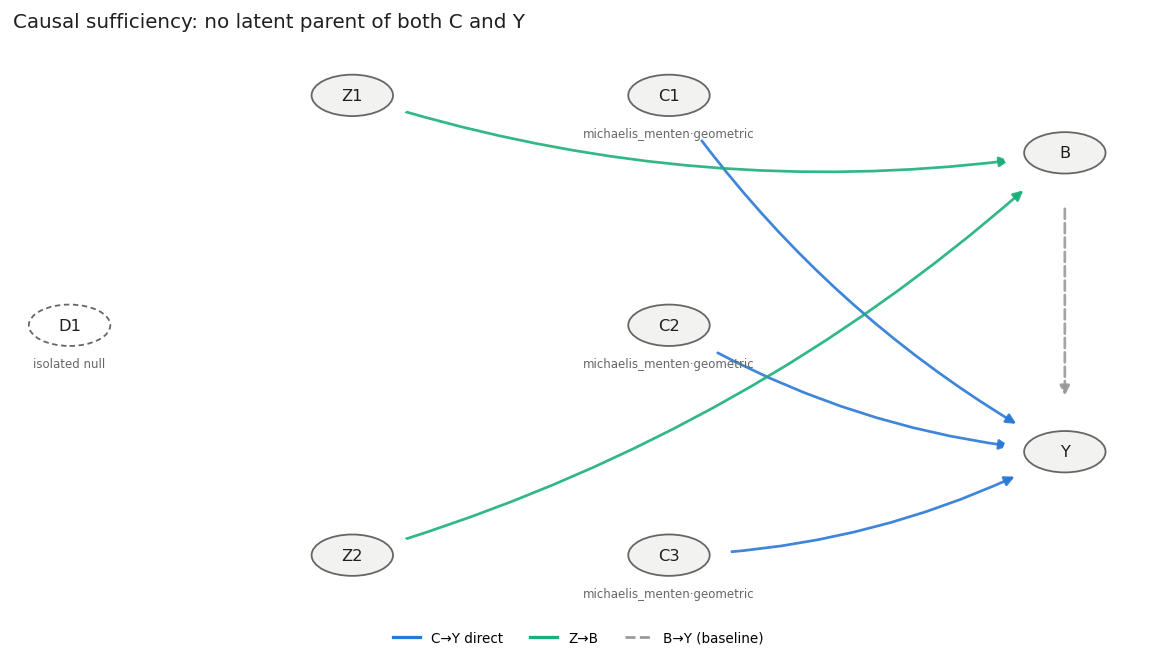

In [3]:
def show(plot_fn, w, title):
    path = os.path.join(tempfile.mkdtemp(), 'fig.png')
    plot_fn(w, path, title)
    display(Image(filename=path))

show(viz.plot_dag, world, 'Causal sufficiency: no latent parent of both C and Y')

The model-facing table is dated spend, controls, and sales — nothing else.
Truth series (`contributions_observed`, `baseline`, the parameters) stay on
our side of the fence, for scoring only.

,date,C1,C2,C3,Z1,Z2,Y
0,2025-01-06,1.873039,0.984453,4.164276,-0.991806,0.298971,9.211697
1,2025-01-13,6.880193,0.862633,4.267417,-0.947913,0.226578,9.343041
2,2025-01-20,3.412878,1.999580,3.772402,-0.892713,0.293091,9.446119
3,2025-01-27,2.494901,0.530230,4.424141,-0.817819,0.306842,9.278026
4,2025-02-03,1.670491,0.190268,8.536763,-0.753368,0.353219,9.274173


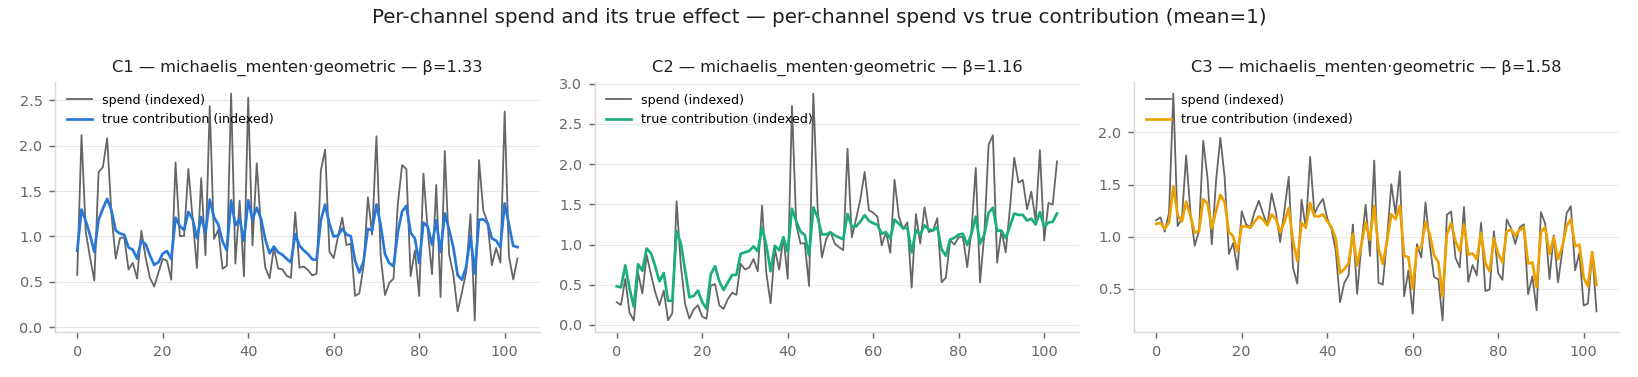

In [4]:
CHANNELS = [f'C{k + 1}' for k in range(world.K)]
CONTROLS = [f'Z{m + 1}' for m in range(world.M)]
frame = pd.DataFrame({'date': pd.date_range('2025-01-06', periods=world.T, freq='W-MON')})
for k, name in enumerate(CHANNELS):
    frame[name] = world.data['channels'][:, k]
for m, name in enumerate(CONTROLS):
    frame[name] = world.data['controls'][:, m]
frame['Y'] = world.data['sales']
X, y = frame.drop(columns='Y'), frame['Y']
display(frame.head())

show(viz.plot_channels, world, 'Per-channel spend and its true effect')

## 2 · The scoring rule, fixed before any model runs

Per channel, over the weeks from `l_max` on (the first `l_max` weeks depend
on pre-window burn-in history that no fitted model sees, so scoring them
would compare different estimands):

- **cumulative attribution**: posterior median of the summed weekly
  contribution, its equal-tailed 94% interval, relative error, and whether
  the interval covers the truth;
- **weekly shape**: correlation between the posterior-mean path and the true
  path.

Same function for every model. `geometry` reports what the sampler itself
says: divergences, worst r-hat, smallest bulk ESS.

In [5]:
START = cfg.l_max
TRUTH = np.asarray(world.data['contributions_observed'])

def score(samples, dim, label):
    """Cumulative + shape recovery of per-channel contributions."""
    s = samples.isel(date=slice(START, None))
    totals = s.sum('date').quantile([0.03, 0.5, 0.97], dim=('chain', 'draw'))
    mean_path = s.mean(('chain', 'draw'))
    rows = []
    for k, name in enumerate(CHANNELS):
        true_path = TRUTH[START:, k]
        true_total = float(true_path.sum())
        lo, med, hi = (float(totals.sel({dim: name, 'quantile': q}))
                       for q in (0.03, 0.5, 0.97))
        rows.append({
            'model': label, 'channel': name,
            'true_total': true_total, 'post_median': med,
            'low_94': lo, 'high_94': hi,
            'rel_error': abs(med - true_total) / abs(true_total),
            'covered_94': bool(lo <= true_total <= hi),
            'shape_corr': float(np.corrcoef(true_path, np.asarray(mean_path.sel({dim: name})))[0, 1]),
        })
    return pd.DataFrame(rows)

def geometry(idata, label, seconds):
    """Sampler-side facts over EVERY posterior variable, unrounded.

    Deterministics included on purpose: it keeps this table exactly as
    conservative as pymc's own convergence warning, so the two can never
    disagree about how healthy a fit looks. `az.rhat` / `az.ess` are used
    directly because `az.summary` rounds r-hat to 2 significant figures,
    which hides exactly the 1.01-1.05 band this notebook cares about.
    """
    stats = idata['sample_stats'] if 'sample_stats' in idata else idata.sample_stats
    rhat = az.rhat(idata)
    ess = az.ess(idata, method='bulk')
    return {
        'model': label,
        'divergences': int(np.asarray(stats['diverging']).sum()),
        'max_rhat': round(max(float(np.nanmax(rhat[v])) for v in rhat.data_vars), 4),
        'min_ess_bulk': round(min(float(np.nanmin(ess[v])) for v in ess.data_vars)),
        'seconds': round(seconds),
    }

print('scored weeks:', world.T - START, 'of', world.T)

scored weeks: 100 of 104


## 3 · The stock MMM attempt

Everything favours it: the component classes match the true mechanism
family exactly, the controls are the true controls, causal sufficiency
holds. Default priors, constant intercept — the standard first fit anyone
would run.

In [6]:
mmm = MMM(
    date_column='date', channel_columns=CHANNELS, control_columns=CONTROLS,
    target_column='Y',
    adstock=GeometricAdstock(l_max=cfg.l_max).set_dims_for_all_priors('channel'),
    saturation=MichaelisMentenSaturation().set_dims_for_all_priors('channel'),
)
mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(['channel_contribution'])
started = time.perf_counter()
mmm_idata = mmm.fit(X, y, draws=1000, tune=1000, chains=4, cores=4,
                    target_accept=0.9, random_seed=11, progressbar=False)
mmm_geo = geometry(mmm_idata, 'MMM (constant intercept)',
                   time.perf_counter() - started)
print(mmm_geo)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [adstock_alpha, saturation_lam, saturation_alpha, gamma_control, y_sigma, intercept_contribution]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Output()

{'model': 'MMM (constant intercept)', 'divergences': 0, 'max_rhat': 1.0027, 'min_ess_bulk': 1845, 'seconds': 8}


In [7]:
mmm_scores = score(
    mmm_idata['posterior']['channel_contribution_original_scale'],
    'channel', 'MMM (constant intercept)',
)
display(mmm_scores.round(3))
print(f"worst cumulative error: {mmm_scores['rel_error'].max():.1%}   "
      f"coverage: {int(mmm_scores['covered_94'].sum())}/3   "
      f"worst shape corr: {mmm_scores['shape_corr'].min():.3f}")

,model,channel,true_total,post_median,low_94,high_94,rel_error,covered_94,shape_corr
0,MMM (constant intercept),C1,55.119,35.078,28.395,45.164,0.364,False,0.984
1,MMM (constant intercept),C2,59.191,70.452,60.789,82.279,0.190,False,1.000
2,MMM (constant intercept),C3,62.895,45.256,35.824,62.404,0.280,False,0.992


worst cumulative error: 36.4%   coverage: 0/3   worst shape corr: 0.984


### The issues, pointed at directly

Three things are true at once, and only together do they tell the story:

1. **The weekly shape is essentially perfect** (correlation ≥ 0.98). The
   response families are right and the spend sweeps them.
2. **The cumulative attribution is badly off** — tens of percent, with 94%
   intervals that exclude the truth.
3. **Every sampler diagnostic is clean**: no divergences, r-hat ≈ 1.00.
   Nothing in the fit warns you that the answer is wrong.

So this is not non-identification (causal sufficiency holds by
construction) and not a sampling failure. It is **misspecification**: the
true baseline is a smooth latent *walk*, and the MMM brings a constant
intercept plus iid noise. The likelihood has to put the walk somewhere, and
the smooth, autocorrelated media terms are the only flexible pieces
available — so the level drifts into the channels and the intervals stay
confidently narrow around a biased split.

In [8]:
residual_truth = (np.asarray(world.data['baseline_intrinsic'])
                  + np.asarray(world.data['confounder_contribution']).sum(1))[START:]
media_truth = np.asarray(world.data['contributions_observed']).sum(1)[START:]
lag1 = float(np.corrcoef(residual_truth[:-1], residual_truth[1:])[0, 1])

print('what the MMM cannot represent (the intrinsic baseline path):')
print(f'  sd(baseline path) / sd(media)  = {residual_truth.std() / media_truth.std():.2f}')
print(f'  lag-1 autocorrelation          = {lag1:.3f}   (iid noise would be ~0)')
print(f'  share of sales sd              = {residual_truth.std() / np.std(np.asarray(world.data["sales"])[START:]):.2f}')

what the MMM cannot represent (the intrinsic baseline path):
  sd(baseline path) / sd(media)  = 0.33
  lag-1 autocorrelation          = 0.459   (iid noise would be ~0)
  share of sales sd              = 0.16


## 4 · The honest upgrade: a time-varying intercept

Once you suspect a latent baseline trend, `time_varying_intercept=True` is
the option pymc-marketing offers: an HSGP prior on the intercept path. It
is the right *kind* of fix — the baseline needs a low-frequency basis, not
a constant.

In [9]:
mmm_tvi = MMM(
    date_column='date', channel_columns=CHANNELS, control_columns=CONTROLS,
    target_column='Y',
    adstock=GeometricAdstock(l_max=cfg.l_max).set_dims_for_all_priors('channel'),
    saturation=MichaelisMentenSaturation().set_dims_for_all_priors('channel'),
    time_varying_intercept=True,
)
mmm_tvi.build_model(X, y)
mmm_tvi.add_original_scale_contribution_variable(['channel_contribution'])
started = time.perf_counter()
tvi_idata = mmm_tvi.fit(X, y, draws=1000, tune=1000, chains=4, cores=4,
                        target_accept=0.9, random_seed=11, progressbar=False)
tvi_geo = geometry(tvi_idata, 'MMM (time-varying intercept)',
                   time.perf_counter() - started)
print(tvi_geo)
tvi_scores = score(
    tvi_idata['posterior']['channel_contribution_original_scale'],
    'channel', 'MMM (time-varying intercept)',
)
display(tvi_scores.round(3))
print(f"worst cumulative error: {tvi_scores['rel_error'].max():.1%}   "
      f"coverage: {int(tvi_scores['covered_94'].sum())}/3")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [adstock_alpha, saturation_lam, saturation_alpha, gamma_control, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, y_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 84 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


...

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

{'model': 'MMM (time-varying intercept)', 'divergences': 1, 'max_rhat': 1.0112, 'min_ess_bulk': 565, 'seconds': 86}


,model,channel,true_total,post_median,low_94,high_94,rel_error,covered_94,shape_corr
0,MMM (time-varying intercept),C1,55.119,35.388,28.875,44.523,0.358,False,0.987
1,MMM (time-varying intercept),C2,59.191,58.646,48.043,70.936,0.009,True,1.000
2,MMM (time-varying intercept),C3,62.895,45.975,37.694,56.444,0.269,False,0.994


worst cumulative error: 35.8%   coverage: 1/3


Better — the channel that absorbed the most baseline is largely repaired —
but the remaining channels are still tens of percent off, and the intervals
still miss. Two cautions from fitting this same model family across many
seeds of this corpus:

- one seed is not a benchmark; the *size* of the residual attribution error
  varies a lot from world to world;
- the HSGP intercept's length-scale and coefficients are the components
  whose r-hat degrades first when the fit is stressed. **Read MMM point
  estimates on these worlds only after checking r-hat**, because when the
  geometry does break, it breaks silently in exactly those parameters.

## 5 · The posterior oracle: the identification floor

`world.oracle_model()` rebuilds the world's own model form as the posterior:
same prior *definitions* generation used (they physically share code, so
draw and oracle cannot drift), the true structure and families given, the
observed spend/controls/sales attached. By default it **marginalizes the
outcome-side Gaussian paths analytically** — the baseline walk, the latent
demand walks, and the iid sales noise enter as an exact multivariate-normal
covariance, so no latent time series is sampled at all.

It is an *oracle* — it is told the true graph and families, which no real
analyst knows. That is the point: it measures what the **data** identifies,
separating world-is-broken from estimator-cannot-represent-it.

In [10]:
oracle = world.oracle_model()
print('free parameters:', sorted(rv.name for rv in oracle.free_RVs))
started = time.perf_counter()
with oracle:
    oracle_idata = pm.sample(draws=1000, tune=1000, chains=4, cores=4,
                             target_accept=0.9, random_seed=11,
                             progressbar=False)
oracle_geo = geometry(oracle_idata, 'oracle (marginal)',
                      time.perf_counter() - started)
print(oracle_geo)

free parameters: ['adstock_alpha', 'beta', 'delta_db', 'mm_kappa_mult', 'rho_zb', 'rw_b_mean', 'rw_b_std_rel', 'rw_y_std_rel']


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [rw_b_mean, rw_b_std_rel, rw_y_std_rel, beta, delta_db, rho_zb, adstock_alpha, mm_kappa_mult]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


{'model': 'oracle (marginal)', 'divergences': 1, 'max_rhat': 1.0037, 'min_ess_bulk': 1428, 'seconds': 49}


In [11]:
oracle_contrib = (
    oracle_idata.posterior['contributions']
    .rename({'contributions_dim_0': 'date', 'contributions_dim_1': 'channel'})
    .assign_coords(channel=CHANNELS, date=np.arange(world.T))
)
oracle_scores = score(oracle_contrib, 'channel', 'oracle (marginal)')
display(oracle_scores.round(3))
print(f"worst cumulative error: {oracle_scores['rel_error'].max():.1%}   "
      f"coverage: {int(oracle_scores['covered_94'].sum())}/3")

assert oracle_geo['max_rhat'] < 1.01
assert int(oracle_scores['covered_94'].sum()) == 3
assert oracle_scores['rel_error'].max() < 0.15

,model,channel,true_total,post_median,low_94,high_94,rel_error,covered_94,shape_corr
0,oracle (marginal),C1,55.119,54.104,45.375,66.603,0.018,True,0.997
1,oracle (marginal),C2,59.191,59.630,50.912,68.982,0.007,True,1.000
2,oracle (marginal),C3,62.895,67.646,59.529,78.718,0.076,True,1.000


worst cumulative error: 7.6%   coverage: 3/3


And the structural parameters themselves are recovered, not just the series:

In [12]:
rows = []
for name in ('beta', 'adstock_alpha', 'mm_kappa_mult'):
    truth_values = np.asarray(world.params[name])
    draws = oracle_idata.posterior[name]
    mean = np.asarray(draws.mean(('chain', 'draw')))
    lo = np.asarray(draws.quantile(0.03, dim=('chain', 'draw')))
    hi = np.asarray(draws.quantile(0.97, dim=('chain', 'draw')))
    for k, channel in enumerate(CHANNELS):
        rows.append({'parameter': name, 'channel': channel,
                     'true': truth_values[k], 'post_mean': mean[k],
                     'low_94': lo[k], 'high_94': hi[k],
                     'covered': bool(lo[k] <= truth_values[k] <= hi[k])})
recovered = pd.DataFrame(rows)
display(recovered.round(3))
print('parameter coverage:', int(recovered['covered'].sum()), '/', len(recovered))

,parameter,channel,true,post_mean,low_94,high_94,covered
0,beta,C1,1.332,1.258,1.082,1.449,True
1,beta,C2,1.157,1.191,1.033,1.367,True
2,beta,C3,1.575,1.639,1.439,1.869,True
3,adstock_alpha,C1,0.412,0.348,0.248,0.448,True
4,adstock_alpha,C2,0.272,0.293,0.215,0.378,True
5,adstock_alpha,C3,0.241,0.260,0.205,0.341,True
6,mm_kappa_mult,C1,1.368,1.256,0.839,1.491,True
7,mm_kappa_mult,C2,0.857,0.906,0.711,1.258,True
8,mm_kappa_mult,C3,1.435,1.348,1.033,1.496,True


parameter coverage: 9 / 9


## 6 · Side by side

In [13]:
summary = pd.concat([mmm_scores, tvi_scores, oracle_scores], ignore_index=True)
coverage = summary.groupby('model')['covered_94'].sum().astype(int)
geo = pd.DataFrame([mmm_geo, tvi_geo, oracle_geo]).set_index('model')
table = pd.DataFrame({
    'worst rel error': summary.groupby('model')['rel_error'].max(),
    'median rel error': summary.groupby('model')['rel_error'].median(),
    'covered / 3': coverage,
    'divergences': geo['divergences'],
    'max r-hat': geo['max_rhat'],
    'min ESS': geo['min_ess_bulk'],
})
display(table.round(3))

,worst rel error,median rel error,covered / 3,divergences,max r-hat,min ESS
model,,,,,,
MMM (constant intercept),0.364,0.280,0,0,1.003,1845
MMM (time-varying intercept),0.358,0.269,1,1,1.011,565
oracle (marginal),0.076,0.018,3,1,1.004,1428


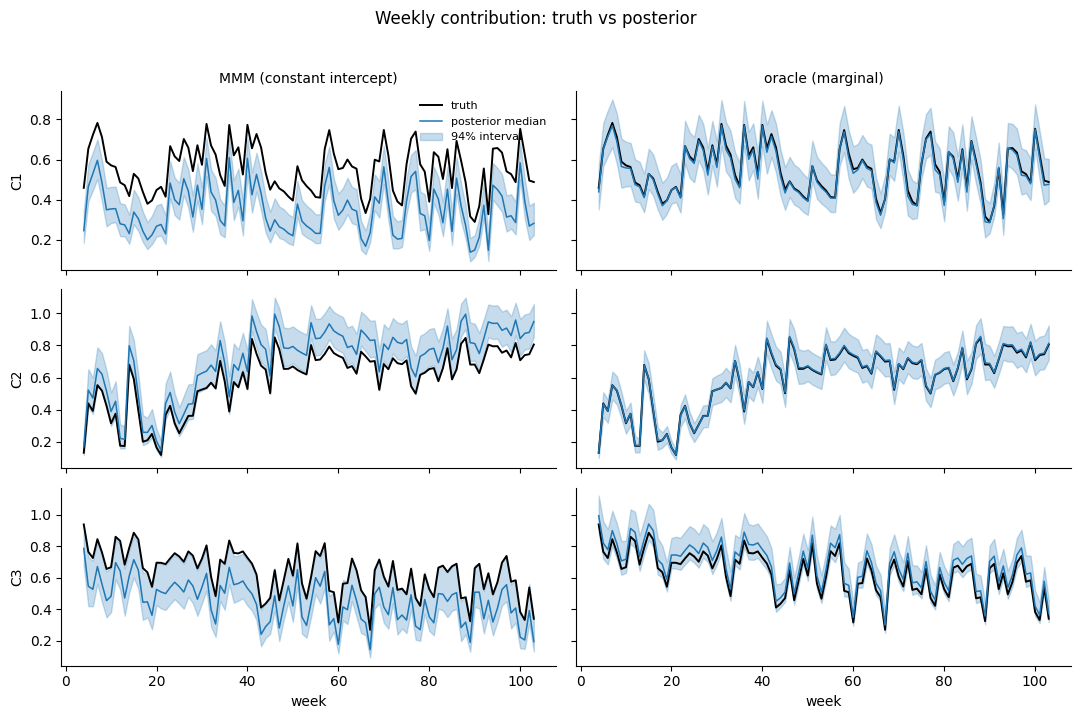

In [14]:
quantiles = {
    'MMM (constant intercept)': mmm_idata['posterior']['channel_contribution_original_scale'],
    'oracle (marginal)': oracle_contrib,
}
weeks = np.arange(world.T)[START:]
fig, axes = plt.subplots(world.K, len(quantiles), figsize=(11, 7),
                         sharex=True, sharey='row')
for col, (label, samples) in enumerate(quantiles.items()):
    s = samples.isel(date=slice(START, None))
    q = s.quantile([0.03, 0.5, 0.97], dim=('chain', 'draw'))
    for k, channel in enumerate(CHANNELS):
        ax = axes[k, col]
        ax.plot(weeks, TRUTH[START:, k], color='black', lw=1.4, label='truth')
        ax.plot(weeks, q.sel(channel=channel, quantile=0.5), color='C0', lw=1.1,
                label='posterior median')
        ax.fill_between(weeks, q.sel(channel=channel, quantile=0.03),
                        q.sel(channel=channel, quantile=0.97), color='C0', alpha=0.25,
                        label='94% interval')
        ax.spines[['top', 'right']].set_visible(False)
        if k == 0:
            ax.set_title(label, fontsize=10)
        if col == 0:
            ax.set_ylabel(channel)
axes[0, 0].legend(frameon=False, fontsize=8)
axes[-1, 0].set_xlabel('week'); axes[-1, 1].set_xlabel('week')
fig.suptitle('Weekly contribution: truth vs posterior', y=1.02)
fig.tight_layout()
plt.show()

The two columns share y-axes per row, so the difference is visible at a
glance: both track the weekly shape, but the MMM's whole band sits **beside**
the truth on the channels that absorbed baseline level, while the oracle's
band sits **on** it.

## 7 · What to take away

- **The world was recoverable.** The oracle — same data, correct error
  model — recovers every cumulative contribution within a few percent, with
  full coverage, r-hat ≈ 1.00, and the true `beta`, `adstock_alpha`,
  `mm_kappa_mult` inside tight posteriors. Any residual gap between an MMM
  and the truth on this corpus is an *estimator* property, not a data
  property.
- **A clean fit is not a correct attribution.** The constant-intercept MMM
  passed every convergence diagnostic while misallocating tens of percent of
  cumulative contribution, because a latent baseline walk existed and its
  likelihood had nowhere to put it.
- **The intercept needs capacity, not luck.** The time-varying intercept is
  the right instinct; on these worlds the baseline requires a genuinely
  low-frequency basis, and its hyperparameters are the first place to look
  when r-hat degrades.
- The knob that *generates* this difficulty — the residual/media amplitude
  ratio — is a declared axis of the corpus. See section 6 of the
  [data-generation tour](index.ipynb), and the posterior-oracle guide for
  the oracle's exact assumptions and concessions.